## Import Needed Libraries

In [1]:
import model
import data
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd


## Load Dataset

In [2]:
train_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_train.npy", ks_npy="../Data/ks_train.npy")
val_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_val.npy", ks_npy="../Data/ks_val.npy")
test_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_test.npy", ks_npy="../Data/ks_test.npy")

train_loader = DataLoader(train_dataset, batch_size=200, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [3]:
# Check loaded file sizes

print('Training Model Outputs Array Size:', len(train_dataset))
print('Validation Model Outputs Array Size:', len(val_dataset))
print('Test Model Outputs Array Size:', len(test_dataset))

# Calculate and display the number of mini-batches
num_train_minibatches = len(train_loader)
num_val_minibatches = len(val_loader)
num_test_minibatches = len(test_loader)

print(f"Number of Mini-Batches: {num_train_minibatches}")
print(f"Number of Mini-Batches: {num_val_minibatches}")
print(f"Number of Mini-Batches: {num_test_minibatches}")



Training Model Outputs Array Size: 800
Validation Model Outputs Array Size: 100
Test Model Outputs Array Size: 100
Number of Mini-Batches: 4
Number of Mini-Batches: 7
Number of Mini-Batches: 7


## Define Hyper/parameters

In [4]:
# Setup for a parametric study

size_kernel = [3, 5, 10, 15] # kernel size, set params_user to 0
size_batch = [16, 32, 64, 100] # batch size, set params_user to 1
reg_params = [1e-2, 1e-3, 1e-4] # regularization parameter, set params_user to 2

params_user = 2 # choose between 0, 1, 2

reg_param = 1e-3

N_epochs = 200 # can vary

# Define loss criteria

criterion = nn.MSELoss()

# total runtime

time_total = time.time()


## Model Instantiation

In [5]:
CNNmodel = model.CNN(channels_in = 8).cuda()

Epoch [1/200] | Train Loss: 1.000551 | Val Loss: 0.988971 | Train Acc (Rel L2): 1.000274
Epoch [2/200] | Train Loss: 1.000110 | Val Loss: 0.988713 | Train Acc (Rel L2): 1.000057
Epoch [3/200] | Train Loss: 1.000044 | Val Loss: 0.988514 | Train Acc (Rel L2): 1.000026
Epoch [4/200] | Train Loss: 0.999919 | Val Loss: 0.988468 | Train Acc (Rel L2): 0.999958
Epoch [5/200] | Train Loss: 0.999900 | Val Loss: 0.988410 | Train Acc (Rel L2): 0.999951
Epoch [6/200] | Train Loss: 0.999848 | Val Loss: 0.988354 | Train Acc (Rel L2): 0.999924
Epoch [7/200] | Train Loss: 0.999838 | Val Loss: 0.988318 | Train Acc (Rel L2): 0.999921
Epoch [8/200] | Train Loss: 0.999831 | Val Loss: 0.988253 | Train Acc (Rel L2): 0.999918
Epoch [9/200] | Train Loss: 0.999788 | Val Loss: 0.988212 | Train Acc (Rel L2): 0.999894
Epoch [10/200] | Train Loss: 0.999725 | Val Loss: 0.988295 | Train Acc (Rel L2): 0.999864
Epoch [11/200] | Train Loss: 0.999701 | Val Loss: 0.988294 | Train Acc (Rel L2): 0.999850
Epoch [12/200] | Tr

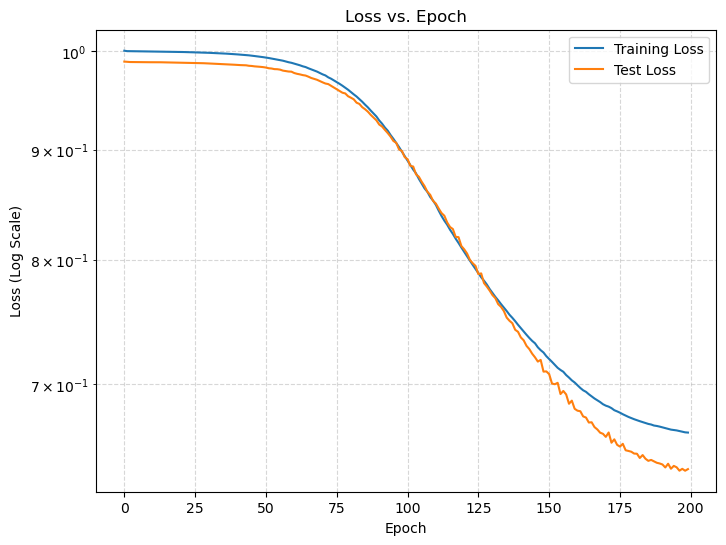

Final Losses: Training Loss - 0.664645, Test Loss - 0.639127
Runtime: 119.61 s


In [6]:
import time
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Parameter study case (Commented out as in original)
# params_user = 0
# if params_user == 0:
#     params = size_kernel
# elif params_user == 1:
#     params = size_batch
# elif params_user == 2:
#     params = reg_params

train_loss_metrics = []
test_loss_metrics = []
train_accuracy_metrics = []
test_accuracy_metrics = []
param_time = []

# Epoch-level history for plotting
train_loss_history = []
test_loss_history = []
train_accuracy_history = []

t_0_main = time.time()

# Define optimizer. Use ADAM with regularization parameter as weight decay
optimizer = optim.Adam(CNNmodel.parameters(), lr=1e-5, weight_decay=0.0)

for epoch in range(1, N_epochs + 1):
    
    # --- TRAINING PHASE ---
    CNNmodel.train()
    running_train_loss = 0.0
    running_train_acc = 0.0
    
    for batch in train_loader:
        # Ensure tensors are floats and on GPU
        x_batch = batch[0].float().cuda()
        y_batch = batch[1].float().cuda()

        # zero the gradients
        optimizer.zero_grad()
        
        # forward
        y_pred = CNNmodel(x_batch)

        # compute loss
        loss = criterion(y_pred, y_batch)
        
        # back propagation
        loss.backward()
        
        # update the parameters theta
        optimizer.step()

        # Calculate relative L2 error (Accuracy proxy) natively on GPU to prevent CPU bottleneck
        with torch.no_grad():
            err = y_pred - y_batch
            accuracy = torch.norm(err) / torch.norm(y_batch)
        
        running_train_loss += loss.item()
        running_train_acc += accuracy.item()

    # Average training metrics for the epoch
    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_acc = running_train_acc / len(train_loader)
    
    train_loss_history.append(avg_train_loss)
    train_accuracy_history.append(avg_train_acc)

    # --- VALIDATION PHASE ---
    CNNmodel.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for test_batch in val_loader:
            test_x_batch = test_batch[0].float().cuda()
            test_y_batch = test_batch[1].float().cuda()

            y_test_pred = CNNmodel(test_x_batch)
            test_loss = criterion(y_test_pred, test_y_batch)
            
            running_val_loss += test_loss.item()
            
    # Average validation metrics for the epoch
    avg_val_loss = running_val_loss / len(val_loader)
    test_loss_history.append(avg_val_loss)

    # Print epoch results
    if epoch % 1 == 0:
        print(f"Epoch [{epoch}/{int(N_epochs)}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Train Acc (Rel L2): {avg_train_acc:.6f}")

# --- METRIC AGGREGATION ---
# Storing the mean of the last 100 epochs (ensure N_epochs > 100 or slice safely)
slice_idx = min(1000, N_epochs)
train_loss_metrics.append(np.mean(train_loss_history[-slice_idx:]))
test_loss_metrics.append(np.mean(test_loss_history[-slice_idx:]))
train_accuracy_metrics.append(np.mean(train_accuracy_history[-slice_idx:]))

# --- PLOTTING ---
plt.figure(figsize=(8,6))
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.gca().set_yscale('log')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Loss vs. Epoch')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

final_train_loss = train_loss_history[-1]
final_test_loss = test_loss_history[-1]

print(f"Final Losses: Training Loss - {final_train_loss:.6f}, Test Loss - {final_test_loss:.6f}")

t_1_main = time.time()
runtime = t_1_main - t_0_main
print(f"Runtime: {runtime:.2f} s")
param_time.append(runtime)

In [7]:
import torch
import numpy as np
from tqdm import tqdm

# ==========================================
# 1. EVALUATION LOOP OVER TEST LOADER
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure the CNN/GRU is in evaluation mode
CNNmodel.eval()

all_A_true = []
all_A_pred = []

print(f"Starting evaluation over {len(val_loader.dataset)} test samples...")

with torch.no_grad(): # No gradients needed for direct inference
    for batch in tqdm(val_loader, desc="Evaluating Test Set"):
        
        # Depending on your dataset, batch[0] is the input (sensor data) 
        # and batch[1] is the target (the true A values)
        x_batch = batch[0].float().cuda()
        y_batch = batch[1].float().cuda()
        
        # Direct forward pass to predict the A values
        y_pred = CNNmodel(x_batch)
        
        # Store results (appending the whole batch at once is much faster)
        all_A_true.append(y_batch.cpu().numpy())
        all_A_pred.append(y_pred.cpu().numpy())

# ==========================================
# 2. RMSE CALCULATION & REPORTING
# ==========================================
# Concatenate the lists of batches into single massive arrays
# Final Shape: [total_samples, 6]
all_A_true = np.concatenate(all_A_true, axis=0)
all_A_pred = np.concatenate(all_A_pred, axis=0)

# Calculate Squared Errors
squared_errors = (all_A_pred - all_A_true) ** 2

# Calculate RMSE per parameter (column-wise)
rmse_per_param = np.sqrt(np.mean(squared_errors, axis=0))

# Calculate Total Overall RMSE across all parameters and samples
overall_rmse = np.sqrt(np.mean(squared_errors))

# Output the results
param_names = ["A_ads", "A_des", "A_std", "A_fst", "A_slw", "A_oxi"]

print("\n" + "="*40)
print("DIRECT INVERSE MODEL RMSE RESULTS")
print("="*40)
print(f"Overall Total RMSE: {overall_rmse:.6f}\n")

for i, name in enumerate(param_names):
    # Depending on the output size of your model, make sure it matches 6
    if i < len(rmse_per_param):
        print(f"{name:6s} RMSE: {rmse_per_param[i]:.6f}")

Starting evaluation over 100 test samples...


Evaluating Test Set: 100%|██████████| 7/7 [00:00<00:00, 28.43it/s]


DIRECT INVERSE MODEL RMSE RESULTS
Overall Total RMSE: 0.819781

A_ads  RMSE: 0.998576
A_des  RMSE: 1.001617
A_std  RMSE: 0.926637
A_fst  RMSE: 0.238683
A_slw  RMSE: 0.342451
A_oxi  RMSE: 0.999478


## Training Loop

In [ ]:
# Parameter study case: select which parameter to vary

# if params_user == 0:
#     params = size_kernel
# elif params_user == 1:
#     params = size_batch
# elif params_user == 2:
#     params = reg_params

train_loss_metrics = []
test_loss_metrics = []
train_accuracy_metrics = []
test_accuracy_metrics = []

param_time = []

# for param in params:

#     if params_user == 0:
#         k = param
#         N_batch = 100
#         reg_param = 1e-3
#     elif params_user == 1:
#         N_batch = param
#         k = 3
#         reg_param = 1e-3
#     elif params_user == 2:
#         reg_param = param
#         k = 3
#         N_batch = 100

# Per epoch
    
train_loss_history = []
test_loss_history = []
train_accuracy_history = []
test_accuracy_history = []

t_0 = time.time()

t_0_main = time.time()

# Define optimizer. Use ADAM with regularization parameter as weight decay

optimizer = optim.Adam(CNNmodel.parameters(), lr=1e-3,weight_decay = 0)

for epoch in range(1, N_epochs + 1):
#for epoch in range(2):
    for batch in train_loader:
        x_batch = batch[0].cuda()
        y_batch = batch[1].cuda()

        # zero the gradients
        
        optimizer.zero_grad()
        
        # forward
            
        y_pred = CNNmodel(x_batch)

        # compute loss
        
        loss = criterion(y_pred[:], y_batch[:])
        
        # back propagation
        
        loss.backward()
        
        # update the parameters theta
        
        optimizer.step()

        err = y_pred - y_batch
        error = err.cpu().detach().numpy()
        y_b = y_batch.cpu().detach().numpy()
        accuracy = np.linalg.norm(error) / np.linalg.norm(y_b)
        
        train_accuracy_history.append(accuracy)
        train_loss_history.append(loss.item())

    with torch.no_grad():
        
        CNNmodel.eval()
        
        for test_batch in val_loader:
            test_x_batch = test_batch[0].cuda()
            test_y_batch = test_batch[1].cuda()

        y_test_pred = CNNmodel(torch.Tensor(test_x_batch).to(torch.float32))

        test_loss = criterion(y_test_pred, torch.Tensor(test_y_batch).to(torch.float32))
        test_loss_history.append(test_loss.item())

    #    test_acc = np.abs(y_test_pred.to("cpu").detach().numpy() - test_A) / test_A
    #    test_acc[~np.isfinite(test_acc)] = 0
    #    test_accuracy = np.nanmean(test_acc)
    #    test_accuracy_history.append(test_accuracy)

        CNNmodel.train()

    if epoch % 1 == 0: # asumming N_epochs/20 is an integer
        print(f"Epoch [{epoch}/{int(N_epochs)}],")
        print(f"Data: Loss: {loss.item()} Accuracy: {accuracy}")

train_loss_metrics.append(np.mean(train_loss_history[-1000:]))
test_loss_metrics.append(np.mean(test_loss_history[-1000:]))
train_accuracy_metrics.append(np.mean(train_accuracy_history[-1000:]))
# test_accuracy_metrics.append(np.mean(test_accuracy_history[-1000:]))

plt.figure(figsize = (8,6))
plt.box(True)
plt.plot(train_loss_history, label = "Training Loss")
plt.plot(test_loss_history, label = "Test Loss")
plt.gca().set_yscale('log')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Loss vs. Epoch')
plt.show()

final_train_loss = train_loss_history[-1]
final_test_loss = test_loss_history[-1]

print(f"Final Losses: Training Loss - {final_train_loss}, Test Loss - {final_test_loss}")

t_1_main = time.time()

print(f"Runtime {t_1_main - t_0_main} s")
param_time.append(t_1_main - t_0_main)
    

Apply Trained Model to Real Experimental Measured Downstream NOx

In [ ]:
# Alternative data load that keeps inputs and outputs separate

outputs_train = np.load("../Data/outputs_train.npy").astype(np.float32)
outputs_val   = np.load("../Data/outputs_val.npy").astype(np.float32)
outputs_test  = np.load("../Data/outputs_test.npy").astype(np.float32)

As_train = np.load("../Data/ks_train.npy").astype(np.float64)
As_val   = np.load("../Data/ks_val.npy").astype(np.float64)
As_test  = np.load("../Data/ks_test.npy").astype(np.float64)

print("Training Samples:", outputs_train.shape)
print("Validation Samples:  ", outputs_val.shape)
print("Test Samples: ", outputs_test.shape)

print("Training As:", As_train.shape)
print("Validation As:  ", As_val.shape)
print("Test As: ", As_test.shape)

print("Total Datasets:", len(As_train) + len(As_val) + len(As_test))

In [ ]:
# Load operating-condition signals from NEDC_lite.mat

mat_path = "../Data/NEDC_lite.mat"

mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

def get_signal(name):
    return np.asarray(mat[name].signals.values, dtype=np.float32).reshape(-1)

F_NOx = get_signal("F_NOx_sensor")    # upstream NOx
Temp = get_signal("Temp")             # exhaust temp
O2 = get_signal("O2")                 # O2
ExhaustFlow = get_signal("ExhaustFlow")
Adblue = get_signal("adblue_mg")      # Adblue signal
O2 = get_signal("O2")                 # O2
Temp_DOC_up = get_signal("Temp_DOC_up")       # temp upstream of DOC

# Common signals for all simulations
# Shape: [time, 5]
base_signal_stack = np.stack(
    [F_NOx, Temp, O2, ExhaustFlow, Adblue, O2, Temp_DOC_up],
    axis=1
)

base_signals = np.transpose(base_signal_stack)

print("Base Signals:", base_signals.shape)

In [ ]:
# Full length is 11993, which can be slow for CNN.
# DOWNSAMPLE = 10 gives around 1200 time steps.
# Later, try DOWNSAMPLE = 5 or 1.

DOWNSAMPLE = 1

base_signals = base_signals[::DOWNSAMPLE]
outputs_train = outputs_train[:, ::DOWNSAMPLE]
outputs_val   = outputs_val[:, ::DOWNSAMPLE]
outputs_test  = outputs_test[:, ::DOWNSAMPLE]

print("After downsampling:")
print("base_signals:", base_signals.shape)
print("outputs_train:", outputs_train.shape)

Input Scaling

In [ ]:
# Per-channel min-max scaling for common operating signals
base_min = base_signals.min(axis=1, keepdims=True)
base_max = base_signals.max(axis=1, keepdims=True)

base_scaled = (base_signals - base_min) / (base_max - base_min + 1e-8)

# Downstream NOx scaling using train set only
dno_min = outputs_train.min()
dno_max = outputs_train.max()

def scale_dno(x):
    return (x - dno_min) / (dno_max - dno_min + 1e-8)

outputs_train_scaled = scale_dno(outputs_train)
outputs_val_scaled   = scale_dno(outputs_val)
outputs_test_scaled  = scale_dno(outputs_test)

Label Scaling (log10(A) and z-normalization)

In [ ]:
param_names = [
    "A_ads",
    "A_des",
    "A_std",
    "A_fst",
    "A_slw",
    "A_nh3ox",
]

logA_train = np.log10(As_train)
logA_val   = np.log10(As_val)
logA_test  = np.log10(As_test)

A_mean = logA_train.mean(axis=0, keepdims=True)
A_std = logA_train.std(axis=0, keepdims=True) + 1e-8

y_train = ((logA_train - A_mean) / A_std).astype(np.float32)
y_val   = ((logA_val   - A_mean) / A_std).astype(np.float32)
y_test  = ((logA_test  - A_mean) / A_std).astype(np.float32)

print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

def inverse_transform_A(y_scaled):
    """
    Convert normalized network output back to physical A values.

    """
    
    y_scaled = np.asarray(y_scaled)
    logA = y_scaled * A_std + A_mean

    return 10 ** logA

Loading Dataset

In [ ]:
class SCRSequenceDataset(Dataset):
    def __init__(self, outputs_scaled, labels_scaled, base_scaled):
        self.outputs_scaled = outputs_scaled.astype(np.float32)
        self.labels_scaled = labels_scaled.astype(np.float32)
        self.base_scaled = base_scaled.astype(np.float32)

    def __len__(self):
        return self.outputs_scaled.shape[0]

    def __getitem__(self, idx):
        # downstream NOx for this simulation
        dno = self.outputs_scaled[idx][None, :]   # [time, 1]

        # input sequence:
        # [F_NOx, Temp, O2, ExhaustFlow, Adblue, downstream_NOx]
        x = np.concatenate([self.base_scaled, dno], axis=0)  # [time, 6]

        y = self.labels_scaled[idx]  # [6]

        return torch.from_numpy(x), torch.from_numpy(y)


train_ds = SCRSequenceDataset(outputs_train_scaled, y_train, base_scaled)
val_ds   = SCRSequenceDataset(outputs_val_scaled,   y_val,   base_scaled)
test_ds  = SCRSequenceDataset(outputs_test_scaled,  y_test,  base_scaled)

BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x0, y0 = train_ds[0]
print("One input sequence shape:", x0.shape)
print("One label shape:", y0.shape)

In [ ]:
# This is for proof-of-concept real sensor trace.
# It uses R_NOx_sensor from NEDC_lite.mat as the downstream NOx input.

R_NOx_measured = get_signal("R_NOx_sensor")[::DOWNSAMPLE]
R_NOx_measured_scaled = scale_dno(R_NOx_measured)

#R_NOx_measured_scaled_input = np.transpose(R_NOx_measured_scaled)

print(R_NOx_measured_scaled.shape)

#print("R_NOx_sensor_measured shape:", R_NOx_measured.shape)
#print("R_NOx_sensor_measured_scaled shape:", R_NOx_measured_scaled.shape)

x_real = np.concatenate(
    [base_scaled, R_NOx_measured_scaled[None, :]],
    axis = 0
).astype(np.float32)

x_real_tensor = torch.from_numpy(x_real[None, :, :]).cuda()

CNNmodel.eval()

with torch.no_grad():
    pred_real_scaled = CNNmodel(x_real_tensor).cpu().numpy()

pred_real_A = inverse_transform_A(pred_real_scaled)[0]

#print(pred_real_A)

real_result = pd.DataFrame({
    "parameter": param_names,
    "predicted pre-exponential factor A": pred_real_A,
})

print("\nPredicted constants from real measured R_NOx_sensor:")
print(real_result)


# If your SCR simulator function expects this order:
# [k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox]
# use this reorder:
pred_real_for_scr_model = pred_real_A[[2, 3, 4, 0, 1, 5]]

print("\nReordered for SCR model [A_std, A_fst, A_slw, A_ads, A_des, A_nh3ox]:")
print(pred_real_for_scr_model)

SCR Model

In [ ]:
def run_SCR_model(
    A_std_0,
    A_fst_0,
    A_slw_0,
    A_ads_0,
    A_des_0,
    A_nh3ox_0,
):

    from scipy.integrate import solve_ivp

    # ---------- Lookup tables ----------
    NO_RATIO_BP = np.array(
        [131.3121, 161.1298, 224.8357, 265.8866, 322.246, 363.2026, 415.0273, 469.8143, 511.78],
        dtype=float,
    )
    NO_RATIO_TBL = np.array(
        [0.785714, 0.979592, 0.360825, 0.324138, 0.366906, 0.497227, 0.617626, 0.702214, 0.761749],
        dtype=float,
    )

    DENSITY_BP = np.array(
        [260, 280, 300, 350, 400, 450, 500, 600, 800, 1000, 1200, 1400],
        dtype=float,
    )
    DENSITY_TBL = np.array(
        [1.340, 1.245, 1.161, 0.995, 0.871, 0.774, 0.696, 0.580, 0.435, 0.348, 0.290, 0.249],
        dtype=float,
    )

    # ---------- Parameters ----------
    PARAMS = {
        "A_std_0": A_std_0,
        "A_fst_0": A_fst_0,
        "A_slw_0": A_slw_0,
        "A_ads_0": A_ads_0,
        "A_des_0": A_des_0,
        "A_nh3ox_0": A_nh3ox_0,
        "E1": 77300.0,
        "E2": 45200.0,
        "E3": 109000.0,
        "E4": -10200.0,
        "E5": 67500.0,
        "E6": 91100.0,
        "R": 8.314,
        "volume_m3": 0.000899,
        "ohm": 900.0,
        "switch_temp_scr_c": 190.0,
        "switch_no_ratio": 0.5,
    }

    def lookup(x, bp, table):
        return np.interp(x, bp, table, left=table[0], right=table[-1])

    def load_timeseries(mat_dict, name):
        obj = mat_dict[name][0, 0]
        t = np.asarray(obj["time"]).squeeze().astype(float)
        v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
        return t, v

    def deduplicate_time(t, *signals):
        _, first_idx = np.unique(t, return_index=True)
        first_idx = np.sort(first_idx)
        out = [t[first_idx]]
        for s in signals:
            out.append(s[first_idx])
        return tuple(out)

    def ppm_to_molm3(ppm):
        return ppm / 22.4 / 1000.0

    def molm3_to_ppm(c):
        return c * 1000.0 * 22.4

    def rate_constants(temp_c):
        T = np.asarray(temp_c, dtype=float) + 273.15
        k_std = PARAMS["A_std_0"] * np.exp(-PARAMS["E1"] / (PARAMS["R"] * T))
        k_fst = PARAMS["A_fst_0"] * np.exp(-PARAMS["E2"] / (PARAMS["R"] * T))
        k_slw = PARAMS["A_slw_0"] * np.exp(-PARAMS["E3"] / (PARAMS["R"] * T))
        k_ads = PARAMS["A_ads_0"] * np.exp(-PARAMS["E4"] / (PARAMS["R"] * T))
        k_des = PARAMS["A_des_0"] * np.exp(-PARAMS["E5"] / (PARAMS["R"] * T))
        k_nh3ox = PARAMS["A_nh3ox_0"] * np.exp(-PARAMS["E6"] / (PARAMS["R"] * T))
        return T, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox

    def gas_exchange_factor(exhaust_mg_s, temp_c):
        T, *_ = rate_constants(temp_c)
        rho = lookup(T, DENSITY_BP, DENSITY_TBL)
        exhaust_kg_s = np.asarray(exhaust_mg_s, dtype=float) * 1e-6
        q_m3_s = exhaust_kg_s / np.maximum(rho, 1e-12)
        F = q_m3_s / PARAMS["volume_m3"]
        return T, rho, F

    def feedforward_adblue(temp_doc_up_c, nox_f_ppm, exhaust_mg_s, temp_scr_up_c):
        no_ratio = lookup(temp_doc_up_c, NO_RATIO_BP, NO_RATIO_TBL)

        mw_no = 14.007 + 15.999
        mw_no2 = 14.007 + 15.999 * 2.0
        mw_nh3 = 14.007 + 1.008 * 3.0
        mw_exh = 29.47

        c_ratio = (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2) / mw_exh
        nh3_vs_nox_ratio = mw_nh3 / (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2)

        exhaust_kg_s = exhaust_mg_s * 1e-6
        nox_mass_like = c_ratio * nox_f_ppm * exhaust_kg_s
        base_nh3 = nh3_vs_nox_ratio * nox_mass_like
        extra_no2_comp = base_nh3 * (1.0 - 2.0 * no_ratio) * 0.333

        alpha_ratio = np.where(
            no_ratio >= PARAMS["switch_no_ratio"],
            base_nh3,
            base_nh3 + extra_no2_comp,
        )

        urea_mg_s = alpha_ratio * (60.0 / 34.0)
        adblue_mg_s = urea_mg_s * (100.0 / 32.4)
        adblue_mg_s = np.where(temp_scr_up_c >= PARAMS["switch_temp_scr_c"], adblue_mg_s, 0.0)

        return adblue_mg_s, no_ratio

    def adblue_to_nh3_in_molm3(adblue_mg_s, exhaust_mg_s):
        return (
            ((adblue_mg_s * (32.4 / 100.0) * (34.0 / 60.0)) / np.maximum(exhaust_mg_s, 1e-12))
            * 1e6
            * (28.8 / 17.0)
            / 1000.0
            / 22.4
        )

    # ---------- Load .mat ----------
    mat = sio.loadmat(mat_path)

    t, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
    _, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")
    _, Dosing = load_timeseries(mat, "Dosing")
    _, Temp = load_timeseries(mat, "Temp")
    _, ExhaustFlow = load_timeseries(mat, "ExhaustFlow")
    _, adblue_mg = load_timeseries(mat, "adblue_mg")
    _, O2 = load_timeseries(mat, "O2")
    _, Temp_DOC_up = load_timeseries(mat, "Temp_DOC_up")

    # use controller dosing exactly like your original code
    adblue_cmd, no_ratio = feedforward_adblue(Temp_DOC_up, F_NOx_sensor, ExhaustFlow, Temp)
    adblue_used = adblue_cmd

    NO_in_ppm = no_ratio * F_NOx_sensor
    NO2_in_ppm = (1.0 - no_ratio) * F_NOx_sensor

    NO_in = ppm_to_molm3(NO_in_ppm)
    NO2_in = ppm_to_molm3(NO2_in_ppm)
    NH3_in = adblue_to_nh3_in_molm3(adblue_used, ExhaustFlow)
    O2_in = O2 * 1e-2

    t_u, Temp_u, ExhaustFlow_u, O2_u, NO_in_u, NO2_in_u, NH3_in_u, R_NOx_u = deduplicate_time(
        t, Temp, ExhaustFlow, O2_in, NO_in, NO2_in, NH3_in, R_NOx_sensor
    )

    def interp_series(tt, arr):
        return float(np.interp(tt, t_u, arr, left=arr[0], right=arr[-1]))

    def rhs(tt, y):
        cno, cno2, theta, cnh3 = np.maximum(y, 0.0)

        temp_c = interp_series(tt, Temp_u)
        exh = interp_series(tt, ExhaustFlow_u)
        o2 = interp_series(tt, O2_u)
        no_in_val = interp_series(tt, NO_in_u)
        no2_in_val = interp_series(tt, NO2_in_u)
        nh3_in_val = interp_series(tt, NH3_in_u)

        _, _, F = gas_exchange_factor(exh, temp_c)
        _, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox = rate_constants(temp_c)

        Rads = k_ads * cnh3 * (1.0 - theta) * PARAMS["ohm"]
        Rdes = k_des * theta * PARAMS["ohm"]
        Roxi = k_nh3ox * o2 * theta * PARAMS["ohm"]
        Rstd = k_std * cno * o2 * theta * PARAMS["ohm"]
        Rfst = k_fst * cno * cno2 * theta * PARAMS["ohm"]
        Rslw = k_slw * cno2 * theta * PARAMS["ohm"]

        dcno = F * no_in_val - 4.0 * Rstd - 2.0 * Rfst - F * cno
        dcno2 = F * no2_in_val - 2.0 * Rfst - 3.0 * Rslw - F * cno2
        dtheta = (Rads - Rdes - 4.0 * Roxi - 4.0 * Rstd - 4.0 * Rfst - 4.0 * Rslw) / PARAMS["ohm"]
        dcnh3 = F * nh3_in_val - Rads + Rdes - 4.0 * Roxi - F * cnh3

        return np.array([dcno, dcno2, dtheta, dcnh3], dtype=float)

    sol = solve_ivp(
        rhs,
        (float(t_u[0]), float(t_u[-1])),
        y0=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
        t_eval=t_u,
        method="BDF",
        rtol=1e-5,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    cno_u, cno2_u, theta_u, cnh3_u = sol.y

    cno = np.interp(t, t_u, cno_u)
    cno2 = np.interp(t, t_u, cno2_u)
    cnh3 = np.interp(t, t_u, cnh3_u)

    NO_out_ppm = molm3_to_ppm(cno)
    NO2_out_ppm = molm3_to_ppm(cno2)
    NH3_out_ppm = molm3_to_ppm(cnh3)

    Model_NOx_ppm = NO_out_ppm + NO2_out_ppm
    Model_sensor_ppm = Model_NOx_ppm + NH3_out_ppm

    return t, Model_sensor_ppm

Run SCR Model With Predicted As

In [ ]:
pred_real_A = np.asarray(pred_real_A, dtype=np.float64).reshape(-1)

print("pred_real_A shape:", pred_real_A.shape)
print(pred_real_A)

if pred_real_A.size != 6:
    raise ValueError(f"Expected 6 predicted constants, but got shape {pred_real_A.shape}")

A_ads, A_des, A_std, A_fst, A_slw, A_nh3ox = pred_real_A

time_s, Model_sensor_ppm = run_SCR_model(
    A_std_0=float(A_std),
    A_fst_0=float(A_fst),
    A_slw_0=float(A_slw),
    A_ads_0=float(A_ads),
    A_des_0=float(A_des),
    A_nh3ox_0=float(A_nh3ox),
)

print("SCR model finished.")
print("time_s shape:", np.shape(time_s))
print("Model_sensor_ppm shape:", np.shape(Model_sensor_ppm))

In [ ]:
# Define load_timeseries function here so it's accessible

def load_timeseries(mat_dict, name):
    obj = mat_dict[name][0, 0]
    t = np.asarray(obj["time"]).squeeze().astype(float)
    v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
    return t, v

# ---- Load only the two measured signals for plotting ----
mat = sio.loadmat(mat_path)

t_f, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
t_r, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")

# ---- Plot ----
plt.figure(figsize=(16, 4))
plt.plot(t_f, F_NOx_sensor, label="F_NOx_sensor", color='red', linewidth=0.8)
plt.plot(t_r, R_NOx_sensor, label="R_NOx_sensor", color='green', linewidth=0.8)
plt.plot(time_s, Model_sensor_ppm, label="Model_sensor_ppm", color='blue', linewidth=0.8)

plt.xlim(0, 1200)   # optional
plt.xlabel("Time [s]")
plt.ylabel("ppm")
plt.title("SCR model response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Load measured downstream NOx: R_NOx_sensor
# ------------------------------------------------------------

# mat_path = "../Data/NEDC_lite.mat"

mat_real = sio.loadmat(
    mat_path,
    squeeze_me=True,
    struct_as_record=False
)

def get_signal_from_mat(mat_dict, name):
    obj = mat_dict[name]
    t = np.asarray(obj.time, dtype=float).reshape(-1)
    v = np.asarray(obj.signals.values, dtype=float).reshape(-1)
    return t, v

t_r, R_NOx_sensor = get_signal_from_mat(mat_real, "R_NOx_sensor")


# ------------------------------------------------------------
# Interpolate model output to measured R_NOx_sensor time
# ------------------------------------------------------------
Model_sensor_interp = np.interp(
    t_r,
    time_s,
    Model_sensor_ppm
)


# ------------------------------------------------------------
# L2 error
# ------------------------------------------------------------
error = Model_sensor_interp - R_NOx_sensor

l2_error = np.linalg.norm(error, ord=2)
relative_l2_error = l2_error / (np.linalg.norm(R_NOx_sensor, ord=2) + 1e-12)

mse = np.mean(error**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(error))

print("Error between R_NOx_sensor and Model_sensor_ppm")
print(f"L2 error          = {l2_error:.6e}")
print(f"Relative L2 error = {relative_l2_error:.6e}")
print(f"RMSE              = {rmse:.6f} ppm")
print(f"MAE               = {mae:.6f} ppm")


# ------------------------------------------------------------
# Plot error
# ------------------------------------------------------------
plt.figure(figsize=(16, 3))
plt.plot(t_r, error, linewidth=0.8)
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Time [s]")
plt.ylabel("Model - Measured [ppm]")
plt.title("Error: Model_sensor_ppm - R_NOx_sensor")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
time_s, Model_sensor_ppm = run_SCR_model(
    A_std_0=3.59e9,
    A_fst_0=8.80e9,
    A_slw_0=3.56e11,
    A_ads_0=4.32,
    A_des_0=4.83e4,
    A_nh3ox_0=6.99e5,
)

# ------------------------------------------------------------
# Load measured downstream NOx: R_NOx_sensor
# ------------------------------------------------------------

# mat_path = "../Data/NEDC_lite.mat"

mat_real = sio.loadmat(
    mat_path,
    squeeze_me=True,
    struct_as_record=False
)

def get_signal_from_mat(mat_dict, name):
    obj = mat_dict[name]
    t = np.asarray(obj.time, dtype=float).reshape(-1)
    v = np.asarray(obj.signals.values, dtype=float).reshape(-1)
    return t, v

t_r, R_NOx_sensor = get_signal_from_mat(mat_real, "R_NOx_sensor")


# ------------------------------------------------------------
# Interpolate model output to measured R_NOx_sensor time
# ------------------------------------------------------------
Model_sensor_interp = np.interp(
    t_r,
    time_s,
    Model_sensor_ppm
)


# ------------------------------------------------------------
# L2 error
# ------------------------------------------------------------
error = Model_sensor_interp - R_NOx_sensor

l2_error = np.linalg.norm(error, ord=2)
relative_l2_error = l2_error / (np.linalg.norm(R_NOx_sensor, ord=2) + 1e-12)

mse = np.mean(error**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(error))

print("Error between R_NOx_sensor and Model_sensor_ppm")
print(f"L2 error          = {l2_error:.6e}")
print(f"Relative L2 error = {relative_l2_error:.6e}")
print(f"RMSE              = {rmse:.6f} ppm")
print(f"MAE               = {mae:.6f} ppm")


# ------------------------------------------------------------
# Plot error
# ------------------------------------------------------------
plt.figure(figsize=(16, 3))
plt.plot(t_r, error, linewidth=0.8)
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Time [s]")
plt.ylabel("Model - Measured [ppm]")
plt.title("Error: Model_sensor_ppm - R_NOx_sensor")
plt.grid(True)
plt.tight_layout()
plt.show()